# Decision Tree Worksheet

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [6]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names=names)

X = data[['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']]
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [9]:
## YOUR CODE HERE
model_overfit = DecisionTreeClassifier(max_depth=10, min_samples_leaf=2)
model_overfit.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=2)

Print accuracy of training and validation data.

In [10]:
## YOUR CODE HERE
y_train_pred_overfit = model_overfit.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred_overfit)}")

y_val_pred_overfit = model_overfit.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred_overfit)}")

Training accuracy: 0.945010183299389
Validation accuracy: 0.6991869918699187


Make a model with a low max-depth and higher minimum sample leafs.

In [11]:
model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10)

Print accuracy of training and validation data.

In [12]:
## YOUR CODE HERE
y_train_pred = model.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred)}")

y_val_pred = model.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred)}")

Training accuracy: 0.7678207739307535
Validation accuracy: 0.7723577235772358


Explain the accuracy results below. 

The high max depth and low min samples leaf model overfits the training data because of these hyperparameters, which is why it has a very high training accuracy but a much lower validation accuracy. The model with a lower max depth and higher min samples leaf is much better at generalizing because the model is not allowed to become too complex, so the training and validation accuracies are much closer, indicating it is not overfitting. 

## Metrics

Plot the ROC curve and print the AUC of the second model.

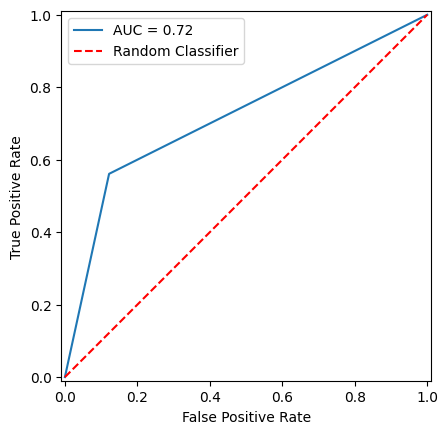

ROC-AUC: 0.7195121951219512


In [19]:
## YOUR CODE HERE
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Classifier")
plt.legend()
plt.show()

print(f"ROC-AUC: {roc_auc}")

Use graphviz to visualize your 2nd tree.

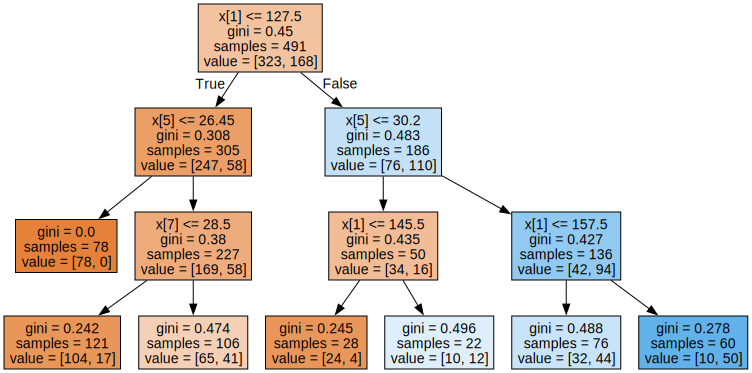

In [21]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(model, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

Which feature the node is for (column n)

Question 2: What is the root feature? Does it make sense as the root feature?

Plas is the root feature, which makes sense because it is the blood sugar level in a diabetes dataset.

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

I think test accuracy would go way down because it is extremely overfit, while training accuracy would likely be almost perfect.

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [22]:
## YOUR CODE HERE

bad_model = DecisionTreeClassifier(max_depth=500, min_samples_leaf=1)
bad_model.fit(X_train, y_train)

y_train_pred = bad_model.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred)}")

y_val_pred = bad_model.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred)}")

Training accuracy: 1.0
Validation accuracy: 0.6991869918699187


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [ ]:
## YOUR CODE HERE
model = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=10)
model.fit(X_train, y_train)

Validation accuracy: 0.7886178861788617


Print accuracy of training and validation data.

In [25]:
## YOUR CODE HERE
y_train_pred = model.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred)}")

y_val_pred = model.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred)}")

Training accuracy: 0.780040733197556
Validation accuracy: 0.7886178861788617


How did the accuracy compare to the decision tree's accuracy?

It got slightly higher

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [29]:
## YOUR CODE HERE
features = pd.DataFrame({
    "feature": ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'],
    "importance": model.feature_importances_
})

print(features.nlargest(3, columns=["importance"]))

  feature  importance
1    plas    0.403329
7     age    0.166329
5    mass    0.153887


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

Accuracy with 1 estimators: 0.7398373983739838
Accuracy with 6 estimators: 0.7804878048780488
Accuracy with 11 estimators: 0.7886178861788617
Accuracy with 16 estimators: 0.7967479674796748
Accuracy with 21 estimators: 0.7886178861788617
Accuracy with 26 estimators: 0.7886178861788617
Accuracy with 31 estimators: 0.7967479674796748
Accuracy with 36 estimators: 0.8130081300813008
Accuracy with 41 estimators: 0.7967479674796748
Accuracy with 46 estimators: 0.7967479674796748
Accuracy with 51 estimators: 0.8048780487804879
Accuracy with 56 estimators: 0.8130081300813008
Accuracy with 61 estimators: 0.8130081300813008
Accuracy with 66 estimators: 0.8048780487804879
Accuracy with 71 estimators: 0.8048780487804879
Accuracy with 76 estimators: 0.8048780487804879
Accuracy with 81 estimators: 0.8048780487804879
Accuracy with 86 estimators: 0.8048780487804879
Accuracy with 91 estimators: 0.8048780487804879
Accuracy with 96 estimators: 0.8048780487804879


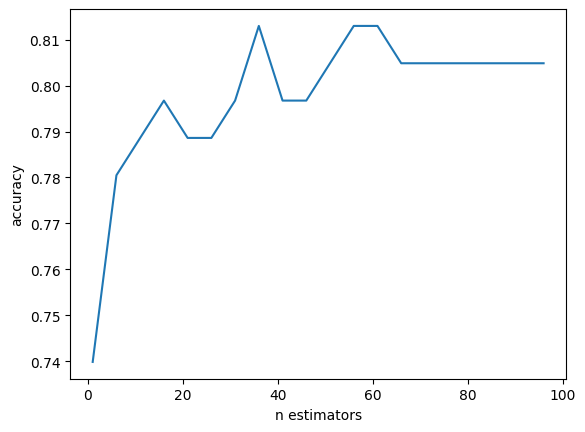

In [35]:
## YOUR CODE HERE
accuracies = []
for n in np.arange(1, 100, 5):
    model = RandomForestClassifier(n_estimators=n, max_depth=3, min_samples_leaf=10, random_state=42)
    model.fit(X_train, y_train)
    accuracy = metrics.accuracy_score(y_val, model.predict(X_val))
    accuracies.append(accuracy)
    print(f"Accuracy with {n} estimators: {accuracy}")

plt.plot(np.arange(1, 100, 5), accuracies)
plt.xlabel("n estimators")
plt.ylabel("accuracy")
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

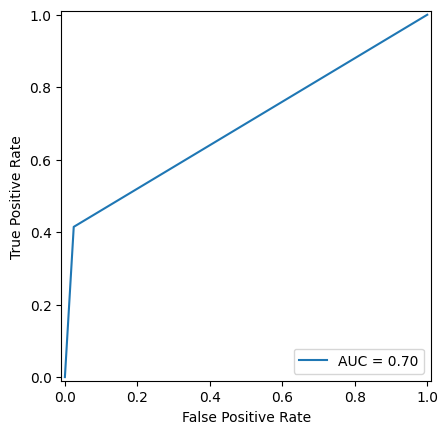

In [39]:
## YOUR CODE HERE
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_pred)
curve = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=metrics.auc(fpr, tpr))
curve.plot()